In [ ]:
!pip install git+https://github.com/m4rz910/NYISOToolkit#egg=nyisotoolkit

  Cloning https://github.com/m4rz910/NYISOToolkit to /tmp/pip-install-vm235hqy/nyisotoolkit_ada93274970e4c84b21273f548007e67
  Running command git clone --filter=blob:none --quiet https://github.com/m4rz910/NYISOToolkit /tmp/pip-install-vm235hqy/nyisotoolkit_ada93274970e4c84b21273f548007e67
  Resolved https://github.com/m4rz910/NYISOToolkit to commit 87d17158d0737485877e6fd14217f2a298097b93
  Preparing metadata (setup.py) ... done


In [ ]:
from nyisotoolkit import NYISOData
import pandas as pd

dfs = []
for year in ['2021', '2022', '2023', '2024', '2025']:
    print(f"Downloading {year}...")
    df = NYISOData(dataset='load_h', year=year).df
    dfs.append(df)

# Combine all years
data = pd.concat(dfs)
print("Done! Shape:", data.shape)
print(data.head())

Done! Shape: (43824, 12)
Name                          CAPITL     CENTRL    DUNWOD    GENESE  \
Time Stamp                                                            
2021-01-01 05:00:00+00:00  1226.8424  1648.7239  601.3552  974.3564   
2021-01-01 06:00:00+00:00  1194.3334  1606.1065  577.8876  931.0276   
2021-01-01 07:00:00+00:00  1171.2119  1572.9724  558.9263  911.0684   
2021-01-01 08:00:00+00:00  1165.9210  1554.8964  546.9387  899.8583   
2021-01-01 09:00:00+00:00  1180.2197  1562.2618  543.7880  900.8782   

Name                          HUD VL     LONGIL    MHK VL    MILLWD  \
Time Stamp                                                            
2021-01-01 05:00:00+00:00  1000.6928  2045.6664  835.0282  313.6039   
2021-01-01 06:00:00+00:00   958.6629  1932.5254  803.8909  306.3881   
2021-01-01 07:00:00+00:00   928.9989  1846.1064  796.5773  301.3826   
2021-01-01 08:00:00+00:00   913.9954  1794.5440  795.1417  294.9369   
2021-01-01 09:00:00+00:00   916.3651  1791.3168  79

In [ ]:
# Timezone fix
data.index = data.index.tz_convert('US/Eastern')

# Sirf NYC zone lo
nyc = data[['N.Y.C.']].copy()
nyc.columns = ['Load_MW']

# Hourly → 15-minute resample
nyc_15min = nyc.resample('15T').interpolate(method='time')

print("15-min data shape:", nyc_15min.shape)
print(nyc_15min.head(10))

15-min data shape: (175293, 1)
                              Load_MW
Time Stamp                           
2021-01-01 00:00:00-05:00  4789.13490
2021-01-01 00:15:00-05:00  4743.51795
2021-01-01 00:30:00-05:00  4697.90100
2021-01-01 00:45:00-05:00  4652.28405
2021-01-01 01:00:00-05:00  4606.66710
2021-01-01 01:15:00-05:00  4571.72010
2021-01-01 01:30:00-05:00  4536.77310
2021-01-01 01:45:00-05:00  4501.82610
2021-01-01 02:00:00-05:00  4466.87910
2021-01-01 02:15:00-05:00  4440.88820


/tmp/ipykernel_6204/2198040990.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  nyc_15min = nyc.resample('15T').interpolate(method='time')


✅ Saved!


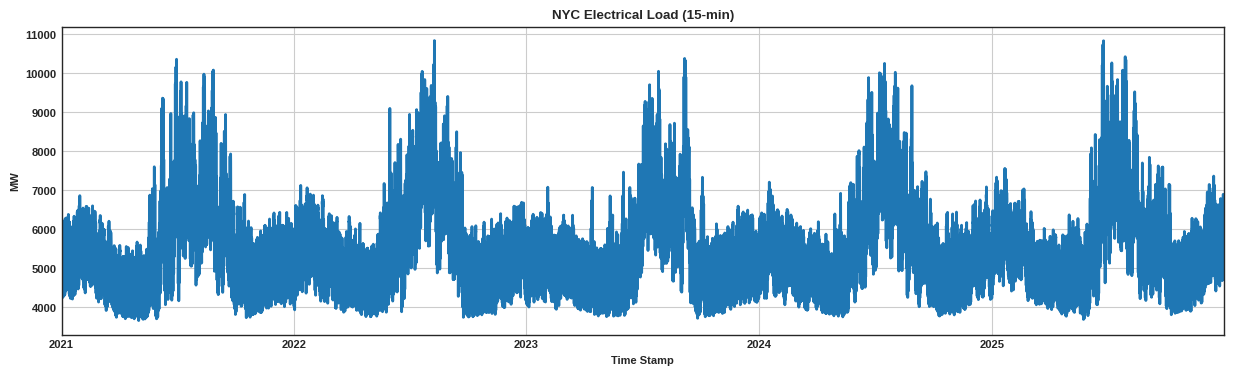

In [ ]:
import matplotlib.pyplot as plt

# Save to CSV
nyc_15min.to_csv("nyiso_nyc_15min.csv")
print("✅ Saved!")

# Plot karo
nyc_15min['Load_MW'].plot(figsize=(15,4), title='NYC Electrical Load (15-min)')
plt.ylabel("MW")
plt.show()

LSTM — Step by Step

Cell 1 — Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

Cell 2 — Data Prepare

In [ ]:
# Same hourly data use karo
df_lstm = nyc['2021-01-01':'2025-12-31'].dropna()

# Normalize (0 to 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_lstm[['Load_MW']])

# Sequences banao (24 ghante dekh ke agla predict karo)
SEQ_LEN = 24

X, y = [], []
for i in range(SEQ_LEN, len(scaled)):
    X.append(scaled[i-SEQ_LEN:i])
    y.append(scaled[i])

X, y = np.array(X), np.array(y)

# Train/Test split 80/20
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (35040, 24, 1) | X_test: (8760, 24, 1)


Cell 3 — LSTM Model Build

In [ ]:
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Cell 4 — Train

Epoch 1/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 27s 48ms/step - loss: 0.0061 - val_loss: 0.0015
Epoch 2/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.0020 - val_loss: 7.8152e-04
Epoch 3/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0014 - val_loss: 4.8734e-04
Epoch 4/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 9.3150e-04 - val_loss: 3.2636e-04
Epoch 5/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 7.0398e-04 - val_loss: 2.2043e-04
Epoch 6/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 6.1087e-04 - val_loss: 1.8175e-04
Epoch 7/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 5.2522e-04 - val_loss: 1.5609e-04
Epoch 8/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 4.7938e-04 - val_loss: 1.1895e-04
Epoch 9/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 4.4885e-04 - val_loss: 1.0132e-04
Epoch 10/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 4.1808e-04 - val_loss: 8.3949e-05


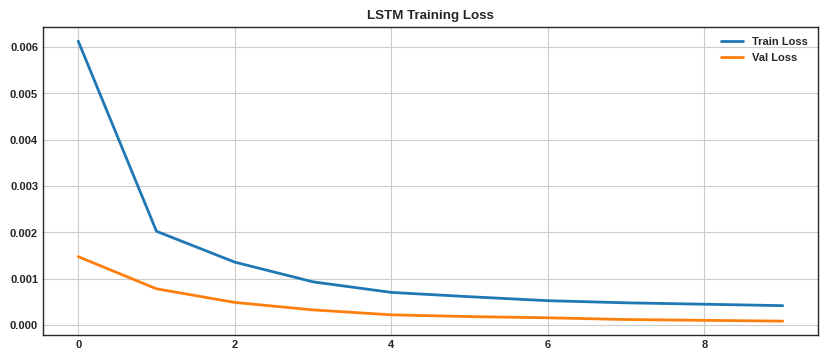

In [ ]:
history = model_lstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Loss plot
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss')
plt.legend()
plt.show()

Cell 5 — Predict + Metrics

In [ ]:
from sklearn.metrics import r2_score

# Predict
y_pred_scaled = model_lstm.predict(X_test)

# Inverse transform
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test)

# Metrics function
def get_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2   = r2_score(actual, predicted)
    return rmse, mae, mape, r2

rmse, mae, mape, r2 = get_metrics(y_actual, y_pred)
print(f"\n📊 LSTM Results:")
print(f"   RMSE : {rmse:.2f} MW")
print(f"   MAE  : {mae:.2f} MW")
print(f"   MAPE : {mape:.2f} %")
print(f"   R²   : {r2:.4f}")

274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

📊 LSTM Results:
   RMSE : 75.46 MW
   MAE  : 55.13 MW
   MAPE : 0.97 %
   R²   : 0.9957


Cell 6 — Plot

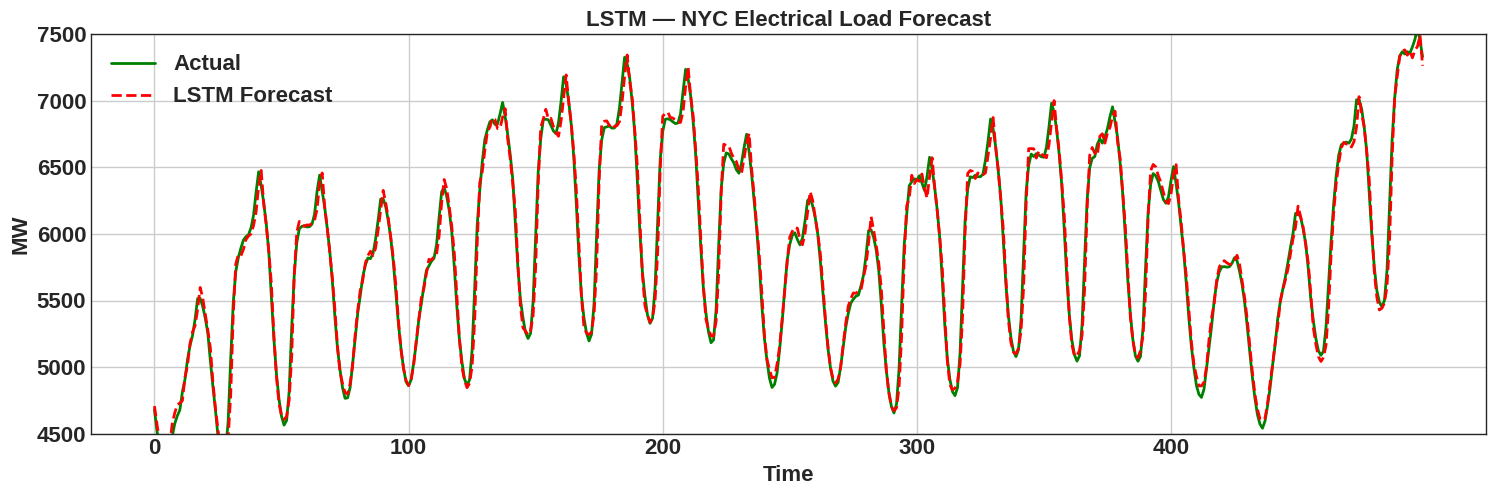

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,5))

plt.plot(y_actual[:500], label='Actual', color='green')
plt.plot(y_pred[:500], label='LSTM Forecast', color='red', linestyle='--')

# 🔥 Fix Y-axis range
plt.ylim(4500, 7500)

# 🔥 Increase grid box spacing inside this range
plt.xticks(np.arange(0, 500, 100), fontsize=16)   # wider boxes (X-axis)
plt.yticks(np.arange(4500, 7501, 500), fontsize=16)  # bigger boxes (Y-axis)

# Grid
plt.grid(True, linewidth=1)

plt.title('LSTM — NYC Electrical Load Forecast', fontsize=16)
plt.xlabel('Time', fontsize=16)
plt.ylabel('MW', fontsize=16)

plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

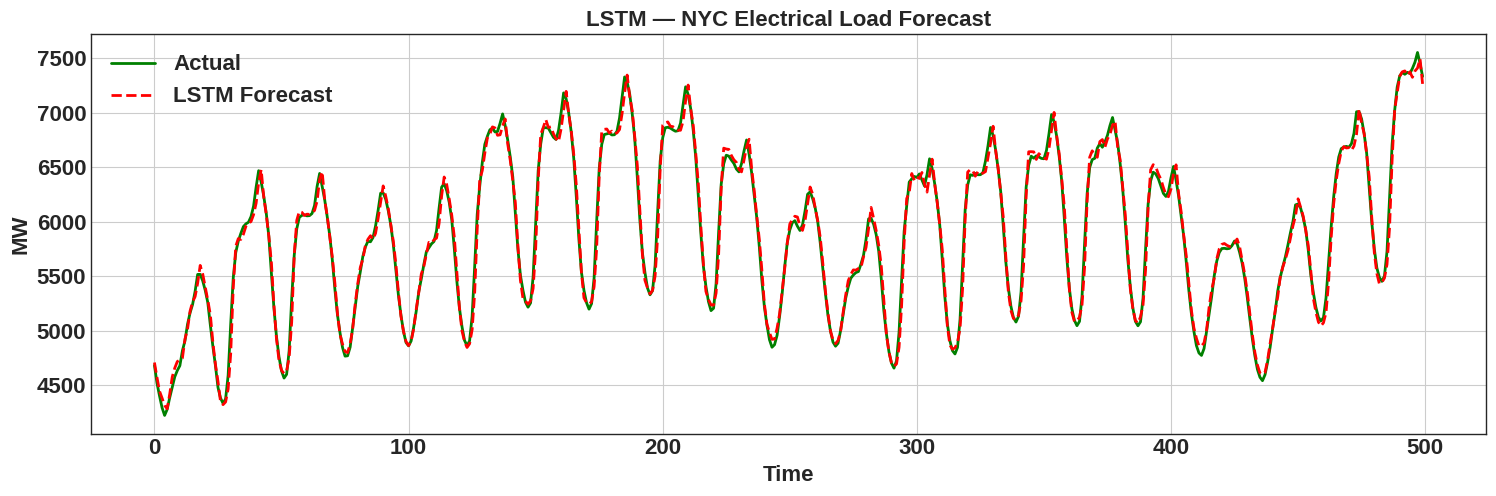

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_actual[:500], label='Actual', color='green')
plt.plot(y_pred[:500],   label='LSTM Forecast', color='red', linestyle='--')
plt.title('LSTM — NYC Electrical Load Forecast', fontsize=16)
plt.xlabel('Time', fontsize=16)
plt.ylabel('MW', fontsize=16)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

GRU — Step by Step

Cell 1 — GRU Model Build

In [ ]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse')
model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 24, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

Cell 2 — Train

Epoch 1/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - loss: 0.0044 - val_loss: 4.4361e-04
Epoch 2/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 0.0012 - val_loss: 3.6591e-04
Epoch 3/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - loss: 8.3588e-04 - val_loss: 1.7441e-04
Epoch 4/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - loss: 6.3333e-04 - val_loss: 1.2507e-04
Epoch 5/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - loss: 5.2482e-04 - val_loss: 1.2376e-04
Epoch 6/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - loss: 4.6631e-04 - val_loss: 9.3963e-05
Epoch 7/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - loss: 4.3885e-04 - val_loss: 1.0931e-04
Epoch 8/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 4.2424e-04 - val_loss: 9.8777e-05
Epoch 9/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - loss: 4.2445e-04 - val_loss: 1.0086e-04
Epoch 10/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - loss: 4.0618e-04 - val_loss: 9.3253e-05


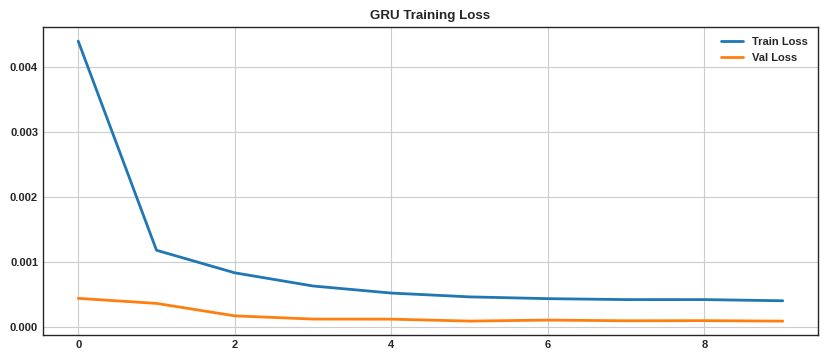

In [ ]:
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Loss plot
plt.figure(figsize=(10,4))
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Val Loss')
plt.title('GRU Training Loss')
plt.legend()
plt.show()

Cell 3 — Predict + Metrics

In [ ]:
# Predict
y_pred_gru_scaled = model_gru.predict(X_test)

# Inverse transform
y_pred_gru = scaler.inverse_transform(y_pred_gru_scaled)

# Metrics
rmse_gru, mae_gru, mape_gru, r2_gru = get_metrics(y_actual, y_pred_gru)
print(f"\n📊 GRU Results:")
print(f"   RMSE : {rmse_gru:.2f} MW")
print(f"   MAE  : {mae_gru:.2f} MW")
print(f"   MAPE : {mape_gru:.2f} %")
print(f"   R²   : {r2_gru:.4f}")

274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step

📊 GRU Results:
   RMSE : 81.36 MW
   MAE  : 58.23 MW
   MAPE : 1.00 %
   R²   : 0.9950


Cell 4 — Plot

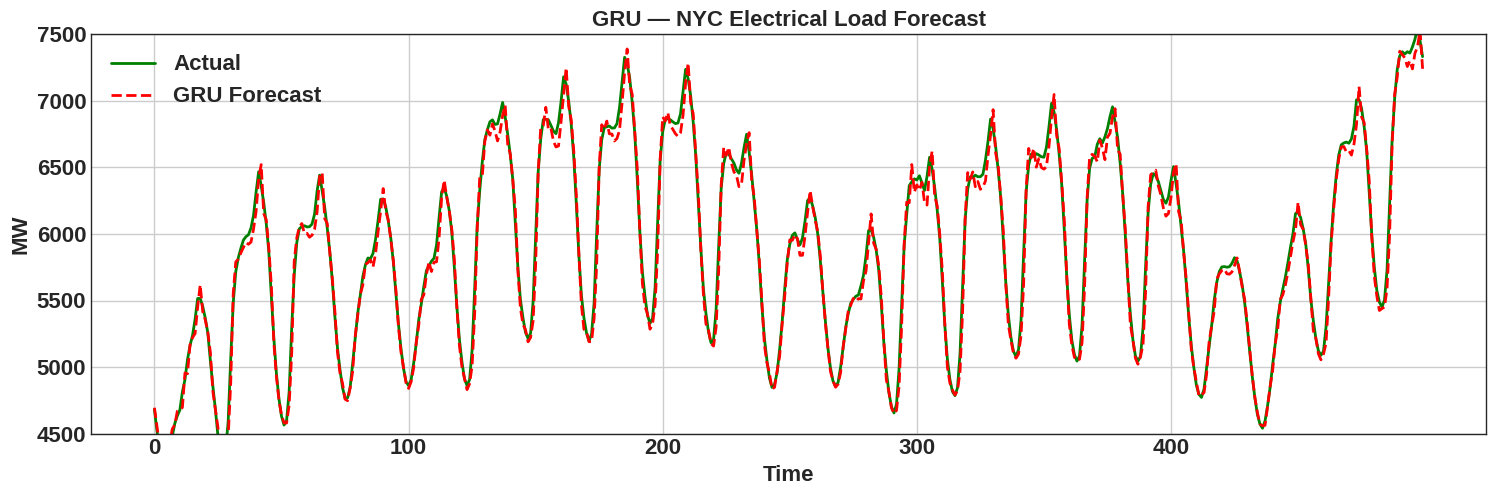

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,5))

plt.plot(y_actual[:500], label='Actual', color='green')
plt.plot(y_pred_gru[:500], label='GRU Forecast', color='red', linestyle='--')


plt.xticks(np.arange(0, 500, 100), fontsize=16)   # bigger horizontal gap
plt.yticks(np.arange(4500, 7501, 500), fontsize=16)  # bigger vertical gap

# Optional: fix range
plt.ylim(4500, 7500)

# Grid
plt.grid(True, linewidth=1)

plt.title('GRU — NYC Electrical Load Forecast', fontsize=16)
plt.xlabel('Time', fontsize=16)
plt.ylabel('MW', fontsize=16)

plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

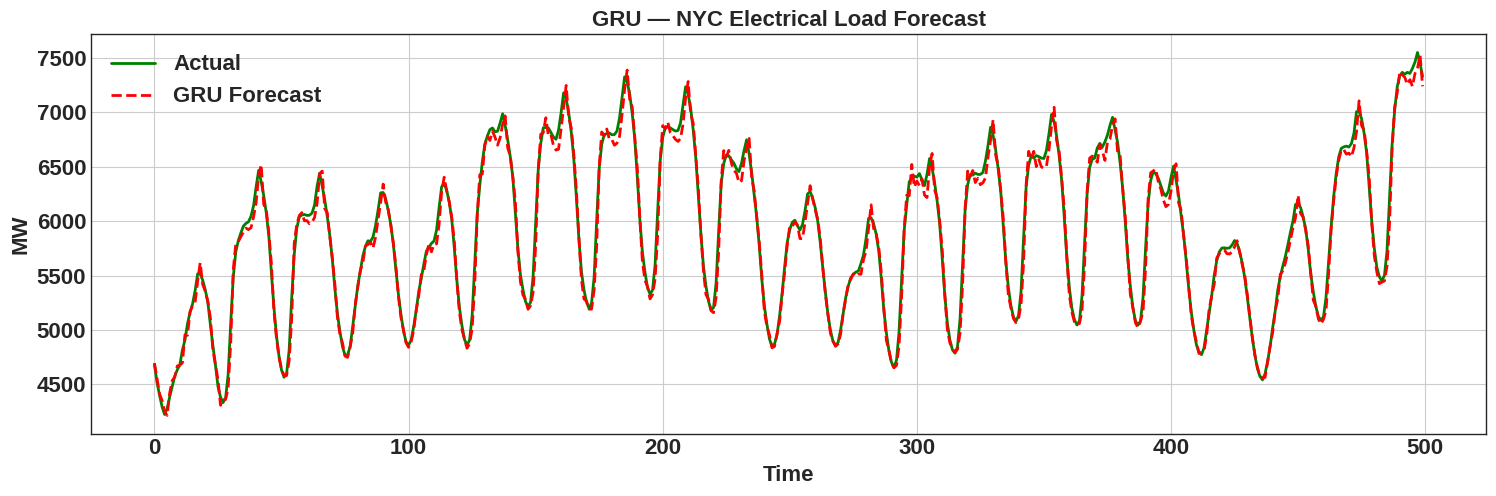

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(y_actual[:500], label='Actual', color='green')
plt.plot(y_pred_gru[:500], label='GRU Forecast', color='red', linestyle='--')
plt.title('GRU — NYC Electrical Load Forecast', fontsize=16)
plt.xlabel('Time', fontsize=16)
plt.ylabel('MW', fontsize=16)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

GBM — Step by Step

Cell 1 — Libraries

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler

Cell 2 — Data Prepare (GBM ke liye alag features)

In [ ]:
# Feature engineering — GBM ko sequences nahi, features chahiye
df_gbm = nyc['2021-01-01':'2025-12-31'].dropna().copy()

# Time-based features banao
df_gbm['hour']       = df_gbm.index.hour
df_gbm['dayofweek']  = df_gbm.index.dayofweek
df_gbm['month']      = df_gbm.index.month
df_gbm['dayofyear']  = df_gbm.index.dayofyear

# Lag features (pichle ghanton ka data)
df_gbm['lag_1']  = df_gbm['Load_MW'].shift(1)
df_gbm['lag_24'] = df_gbm['Load_MW'].shift(24)
df_gbm['lag_168']= df_gbm['Load_MW'].shift(168)  # 1 week

df_gbm.dropna(inplace=True)

# Features aur target
features = ['hour', 'dayofweek', 'month', 'dayofyear', 'lag_1', 'lag_24', 'lag_168']
X_gbm = df_gbm[features]
y_gbm = df_gbm['Load_MW']

# Train/Test split 80/20
split = int(len(X_gbm) * 0.8)
X_train_gbm, X_test_gbm = X_gbm.iloc[:split], X_gbm.iloc[split:]
y_train_gbm, y_test_gbm = y_gbm.iloc[:split], y_gbm.iloc[split:]

print(f"Train: {X_train_gbm.shape} | Test: {X_test_gbm.shape}")

Train: (34924, 7) | Test: (8732, 7)


Cell 3 — Train GBM

In [ ]:
print("Training GBM... (1-2 min)")

model_gbm = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose=1
)

model_gbm.fit(X_train_gbm, y_train_gbm)
print("✅ GBM Training Done!")

Training GBM... (1-2 min)
      Iter       Train Loss   Remaining Time 
         1     1197344.3124           27.71s
         2     1083685.0869           26.95s
         3      980894.6445           26.54s
         4      888160.4811           26.42s
         5      804269.8298           26.10s
         6      728464.4668           26.00s
         7      659969.6432           26.12s
         8      598060.4562           25.98s
         9      542110.8901           25.78s
        10      491523.4036           25.61s
        20      188195.2871           32.68s
        30       75233.7129           36.01s
        40       32090.5371           35.66s
        50       15480.4349           31.98s
        60        8933.2639           28.77s
        70        6066.5709           25.38s
        80        4716.3698           22.47s
        90        4065.5510           19.92s
       100        3707.4338           17.62s
       200        2624.5754            0.00s
✅ GBM Training Done!


Cell 4 — Predict + Metrics

In [ ]:
y_pred_gbm = model_gbm.predict(X_test_gbm)

rmse_gbm, mae_gbm, mape_gbm, r2_gbm= get_metrics(y_test_gbm.values, y_pred_gbm)
print(f"\n📊 GBM Results:")
print(f"   RMSE : {rmse_gbm:.2f} MW")
print(f"   MAE  : {mae_gbm:.2f} MW")
print(f"   MAPE : {mape_gbm:.2f} %")
print(f"   R²   : {r2_gbm:.4f}")


📊 GBM Results:
   RMSE : 62.40 MW
   MAE  : 43.97 MW
   MAPE : 0.75 %
   R²   : 0.9971


Cell 5 — Plot

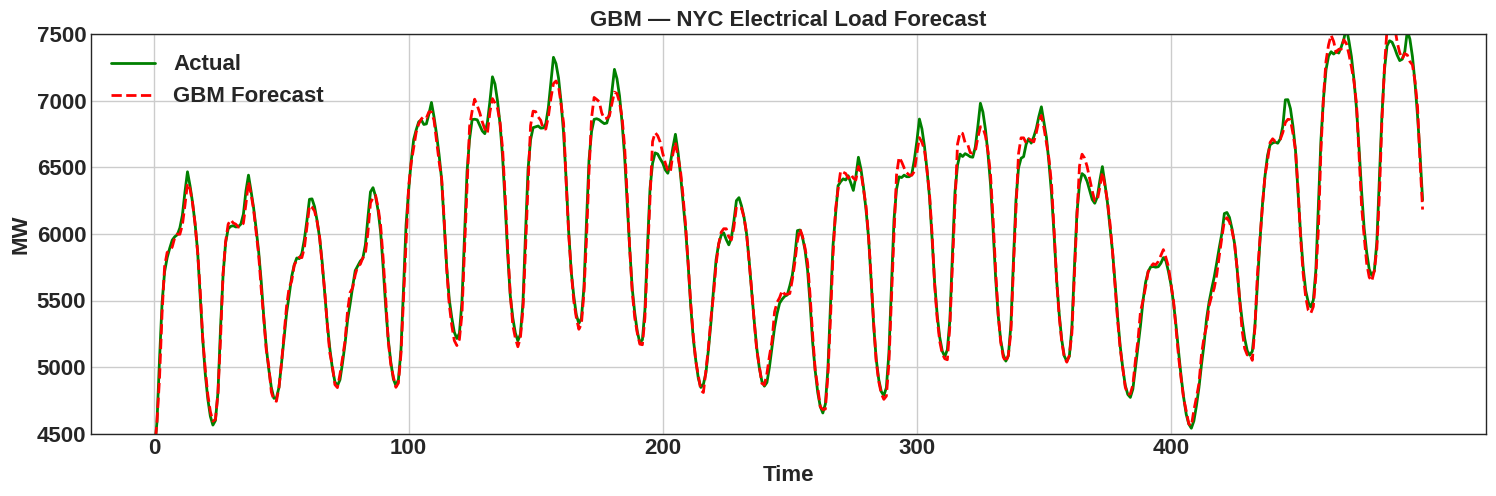

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,5))

plt.plot(y_test_gbm.values[:500], label='Actual', color='green')
plt.plot(y_pred_gbm[:500], label='GBM Forecast', color='red', linestyle='--')

# 🔥 Fix Y range (same readable values)
plt.ylim(4500, 7500)

# 🔥 Increase spacing but keep meaningful values
plt.xticks(np.arange(0, 500, 100), fontsize=16)   # 0,100,200... (clean)
plt.yticks(np.arange(4500, 7501, 500), fontsize=16)  # 4500,5000,...7500

# Grid
plt.grid(True, linewidth=1)

plt.title('GBM — NYC Electrical Load Forecast', fontsize=16)
plt.xlabel('Time', fontsize=16)
plt.ylabel('MW', fontsize=16)

plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

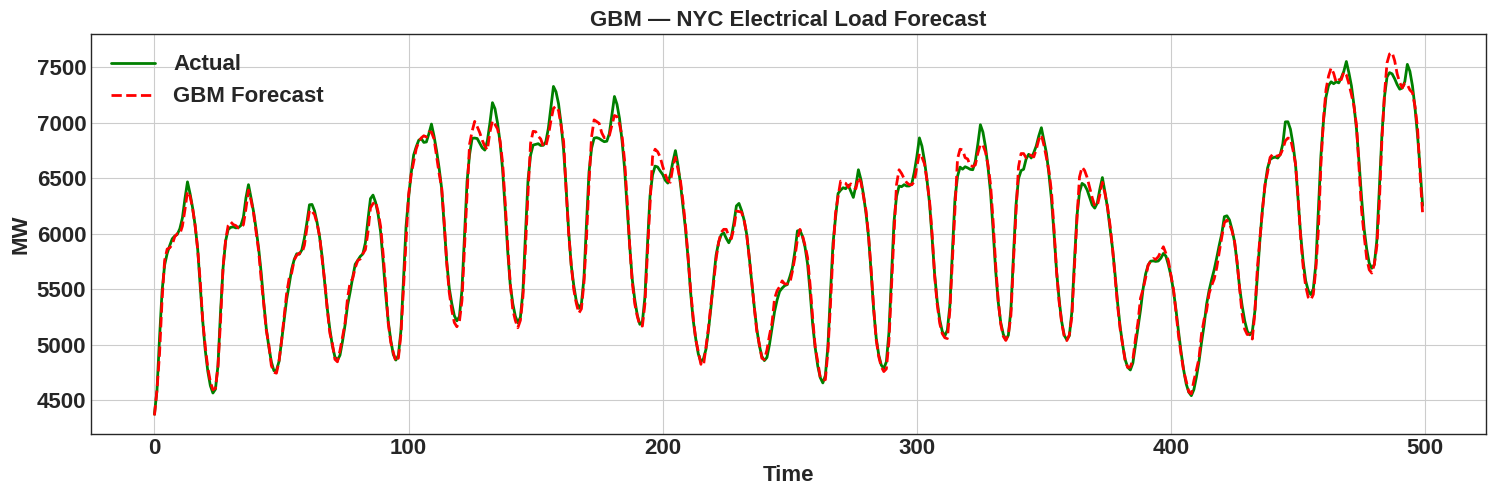

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(y_test_gbm.values[:500], label='Actual', color='green')
plt.plot(y_pred_gbm[:500],        label='GBM Forecast', color='red', linestyle='--')
plt.title('GBM — NYC Electrical Load Forecast', fontsize=16)
plt.xlabel('Time', fontsize=16)
plt.ylabel('MW', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

Cell 6 — Feature Importance

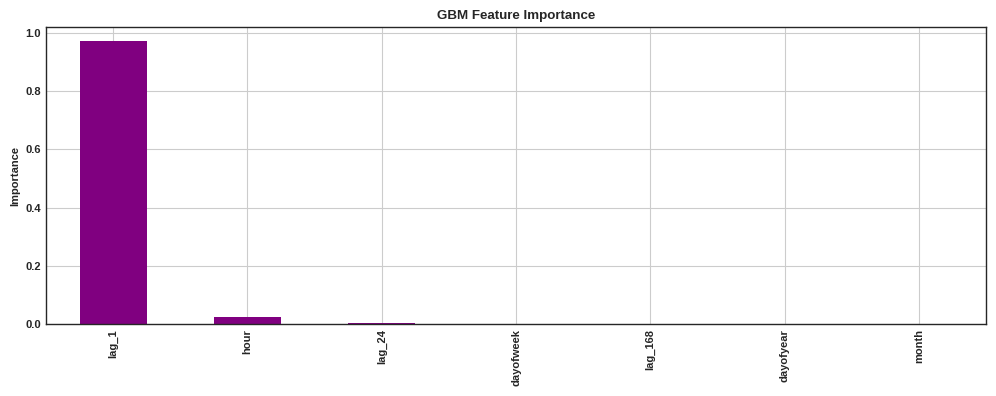

In [ ]:
import pandas as pd

feat_imp = pd.Series(model_gbm.feature_importances_, index=features).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10,4), color='purple', title='GBM Feature Importance')
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Final Comparison — Metrics + Graphs

Cell 1 — Metrics Table

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sabke metrics ek jagah
results = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'GBM'],
    'RMSE':  [rmse,     rmse_gru,  rmse_gbm],
    'MAE':   [mae,      mae_gru,   mae_gbm],
    'MAPE':  [mape,     mape_gru,  mape_gbm],
     'R2':    [r2,       r2_gru,    r2_gbm]
})
print(results)
# ARIMA ke actual values se fill karo
# (jo Cell 5 mein calculate hue تھے)
print("\n📊 Model Comparison Table:")
print(results.to_string(index=False))

  Model       RMSE        MAE      MAPE        R2
0  LSTM  75.463479  55.130007  0.972787  0.995693
1   GRU  81.355036  58.233130  0.997755  0.994995
2   GBM  62.402029  43.965151  0.750611  0.997057

📊 Model Comparison Table:
Model      RMSE       MAE     MAPE       R2
 LSTM 75.463479 55.130007 0.972787 0.995693
  GRU 81.355036 58.233130 0.997755 0.994995
  GBM 62.402029 43.965151 0.750611 0.997057


Cell 2 — Sahi Metrics Fill Karo

In [ ]:
# Apne actual results yahan dalo
results = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'GBM'],
    'RMSE':  [ rmse,     rmse_gru,  rmse_gbm],
    'MAE':   [ mae,      mae_gru,   mae_gbm],
    'MAPE':  [mape,     mape_gru,  mape_gbm],
    'R2':    [r2,   r2_gru,    r2_gbm]
})

print(results)

  Model       RMSE        MAE      MAPE        R2
0  LSTM  75.463479  55.130007  0.972787  0.995693
1   GRU  81.355036  58.233130  0.997755  0.994995
2   GBM  62.402029  43.965151  0.750611  0.997057


Cell 3 — Bar Chart Comparison

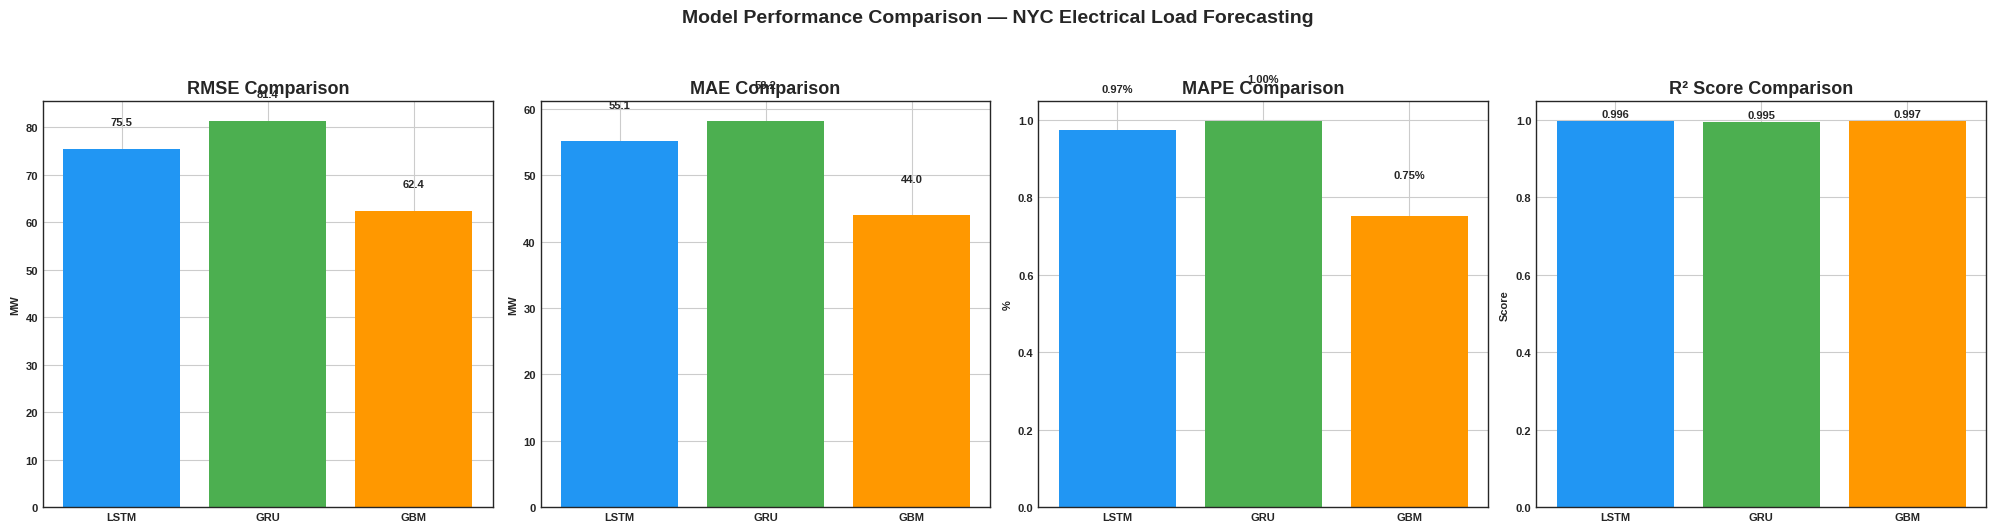

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# RMSE
axes[0].bar(results['Model'], results['RMSE'], color=colors)
axes[0].set_title('RMSE Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MW')
for i, v in enumerate(results['RMSE']):
    axes[0].text(i, v + 5, f'{v:.1f}', ha='center', fontweight='bold')

# MAE
axes[1].bar(results['Model'], results['MAE'], color=colors)
axes[1].set_title('MAE Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MW')
for i, v in enumerate(results['MAE']):
    axes[1].text(i, v + 5, f'{v:.1f}', ha='center', fontweight='bold')

# MAPE
axes[2].bar(results['Model'], results['MAPE'], color=colors)
axes[2].set_title('MAPE Comparison', fontsize=13, fontweight='bold')
axes[2].set_ylabel('%')
for i, v in enumerate(results['MAPE']):
    axes[2].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

# R2
axes[3].bar(results['Model'], results['R2'], color=colors)
axes[3].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[3].set_ylabel('Score')
for i, v in enumerate(results['R2']):
    axes[3].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison — NYC Electrical Load Forecasting',
             fontsize=14, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 4 — Combined Forecast Plot

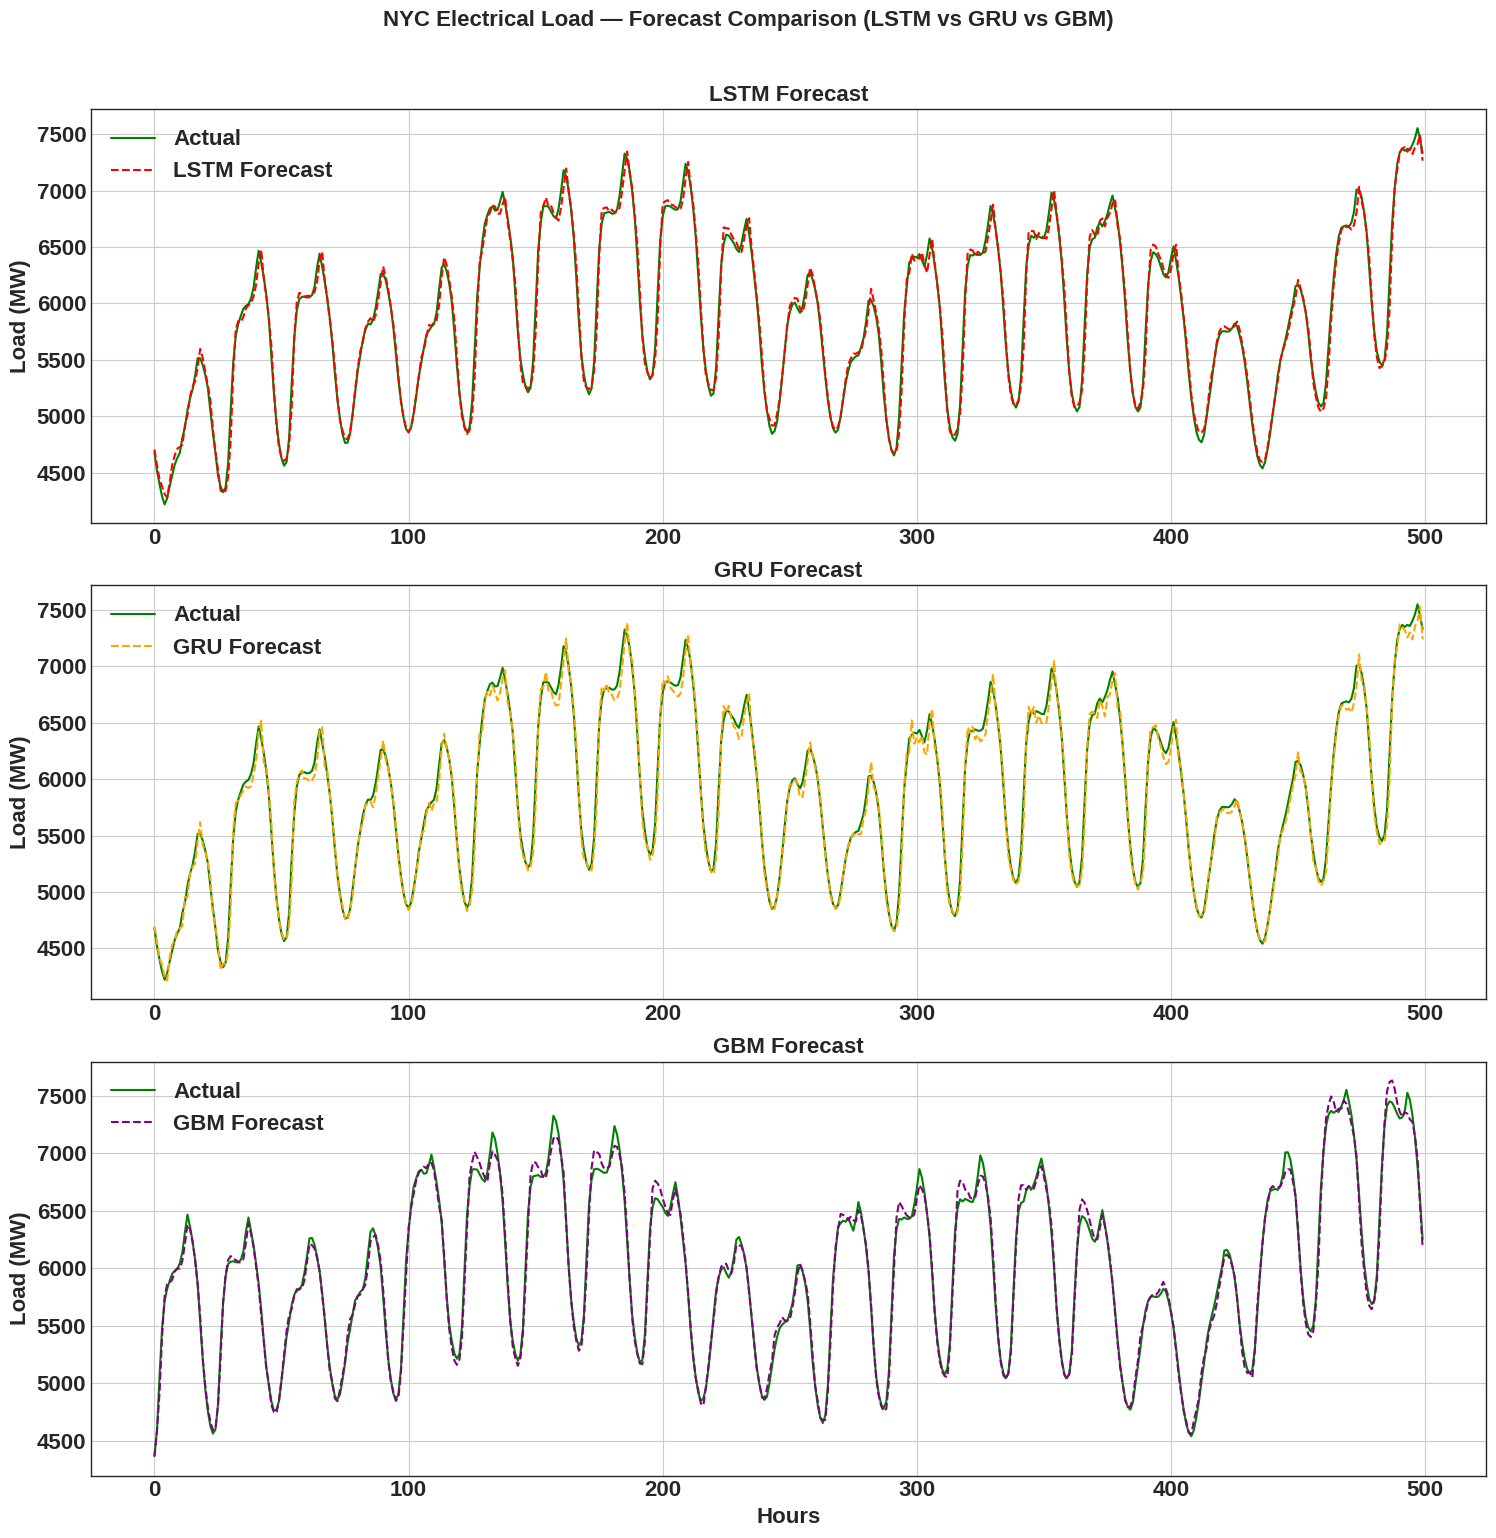

✅ Saved: all_models_forecast.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))  # Now 3 subplots

# LSTM
axes[0].plot(y_actual[:500].flatten(), label='Actual', color='green', linewidth=1.5)
axes[0].plot(y_pred[:500], label='LSTM Forecast', color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('LSTM Forecast', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Load (MW)', fontsize=16)
axes[0].tick_params(labelsize=16)
axes[0].legend(fontsize=16)

# GRU
axes[1].plot(y_actual[:500].flatten(), label='Actual', color='green', linewidth=1.5)
axes[1].plot(y_pred_gru[:500], label='GRU Forecast', color='orange', linewidth=1.5, linestyle='--')
axes[1].set_title('GRU Forecast', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Load (MW)', fontsize=16)
axes[1].tick_params(labelsize=16)
axes[1].legend(fontsize=16)

# GBM
axes[2].plot(y_test_gbm.values[:500], label='Actual', color='green', linewidth=1.5)
axes[2].plot(y_pred_gbm[:500], label='GBM Forecast', color='purple', linewidth=1.5, linestyle='--')
axes[2].set_title('GBM Forecast', fontsize=16, fontweight='bold')
axes[2].set_ylabel('Load (MW)', fontsize=16)
axes[2].set_xlabel('Hours', fontsize=16)
axes[2].tick_params(labelsize=16)
axes[2].legend(fontsize=16)

plt.suptitle('NYC Electrical Load — Forecast Comparison (LSTM vs GRU vs GBM)',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('all_models_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: all_models_forecast.png")

Cell 5 — Best Model Print

In [ ]:
best = results.loc[results['RMSE'].idxmin()]

print(f"\n🏆 Best Model: {best['Model']}")
print(f"   RMSE : {best['RMSE']:.2f} MW")
print(f"   MAE  : {best['MAE']:.2f} MW")
print(f"   MAPE : {best['MAPE']:.2f} %")
print(f"   R2   : {best['R2']:.4f}")

print("\n📋 Full Rankings (by RMSE):")
print(results.sort_values('RMSE').to_string(index=False))


🏆 Best Model: GBM
   RMSE : 62.40 MW
   MAE  : 43.97 MW
   MAPE : 0.75 %
   R2   : 0.9971

📋 Full Rankings (by RMSE):
Model      RMSE       MAE     MAPE       R2
  GBM 62.402029 43.965151 0.750611 0.997057
 LSTM 75.463479 55.130007 0.972787 0.995693
  GRU 81.355036 58.233130 0.997755 0.994995


Cell — CSV Download

In [ ]:
from google.colab import files

# 15-min data download
files.download("nyiso_nyc_15min.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

if we need hourly data

In [ ]:
import pandas as pd
from google.colab import files

# Hourly data save + download
nyc.to_csv("nyiso_nyc_hourly.csv")
files.download("nyiso_nyc_hourly.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cell — Direct Download

In [ ]:
from google.colab import files
files.download("nyiso_nyc_15min.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Agar file na mile toh — Pehle save karo phir download

In [ ]:
from google.colab import files

# Pehle save karo
nyc_15min.to_csv("nyiso_nyc_15min.csv")

# Phir download karo
files.download("nyiso_nyc_15min.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cell 3 — Best Model + Download

In [ ]:
import pandas as pd
from google.colab import files

# Safely collect metrics (using existing variables from kernel state)
try:
    results = pd.DataFrame({
        'Model': ['LSTM', 'GRU', 'GBM', 'Random Forest'],
        'RMSE':  [rmse,      rmse_gru,  rmse_gbm,  rmse_rf],
        'MAE':   [mae,       mae_gru,   mae_gbm,   mae_rf],
        'MAPE':  [mape,      mape_gru,  mape_gbm,  mape_rf],
        'R2':    [r2,        r2_gru,    r2_gbm,    r2_rf]
    })

    # Best model print
    best = results.loc[results['RMSE'].idxmin()]
    print(f"🏆 Best Model: {best['Model']}")
    print(f"   RMSE : {best['RMSE']:.2f} MW")
    print(f"   MAE  : {best['MAE']:.2f} MW")
    print(f"   MAPE : {best['MAPE']:.2f} %")
    print(f"   R2   : {best['R2']:.4f}")

    print("\n📋 Full Rankings (by RMSE):")
    print(results.sort_values('RMSE').to_string(index=False))

    # Download
    files.download('model_comparison.png')
    files.download('all_models_forecast.png')
except NameError as e:
    print(f"Error: {e}")
    print("Please ensure you have run the LSTM, GRU, GBM, and Random Forest training/evaluation cells first.")

Error: name 'rmse_rf' is not defined
Please ensure you have run the LSTM, GRU, GBM, and Random Forest training/evaluation cells first.


Cell 6 — RF Train

In [ ]:
from sklearn.ensemble import RandomForestRegressor

print("🔵 Training Random Forest...")

model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

model_rf.fit(X_train_gbm, y_train_gbm)
print("✅ Random Forest Done!")

🔵 Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    6.5s


✅ Random Forest Done!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   13.7s finished


Cell 7 — RF Predict + Metrics

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred_rf = model_rf.predict(X_test_gbm)

rmse_rf = np.sqrt(mean_squared_error(y_test_gbm.values, y_pred_rf))
mae_rf = mean_absolute_error(y_test_gbm.values, y_pred_rf)
mape_rf = np.mean(np.abs((y_test_gbm.values - y_pred_rf) / y_test_gbm.values)) * 100
r2_rf = r2_score(y_test_gbm.values, y_pred_rf)

print(f"\n📊 Random Forest Results:")
print(f"   RMSE : {rmse_rf:.2f} MW")
print(f"   MAE  : {mae_rf:.2f} MW")
print(f"   MAPE : {mape_rf:.2f} %")
print(f"   R2   : {r2_rf:.4f}")


📊 Random Forest Results:
   RMSE : 72.94 MW
   MAE  : 51.04 MW
   MAPE : 0.87 %
   R2   : 0.9960


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.1s finished


Cell 8 — RF Plot

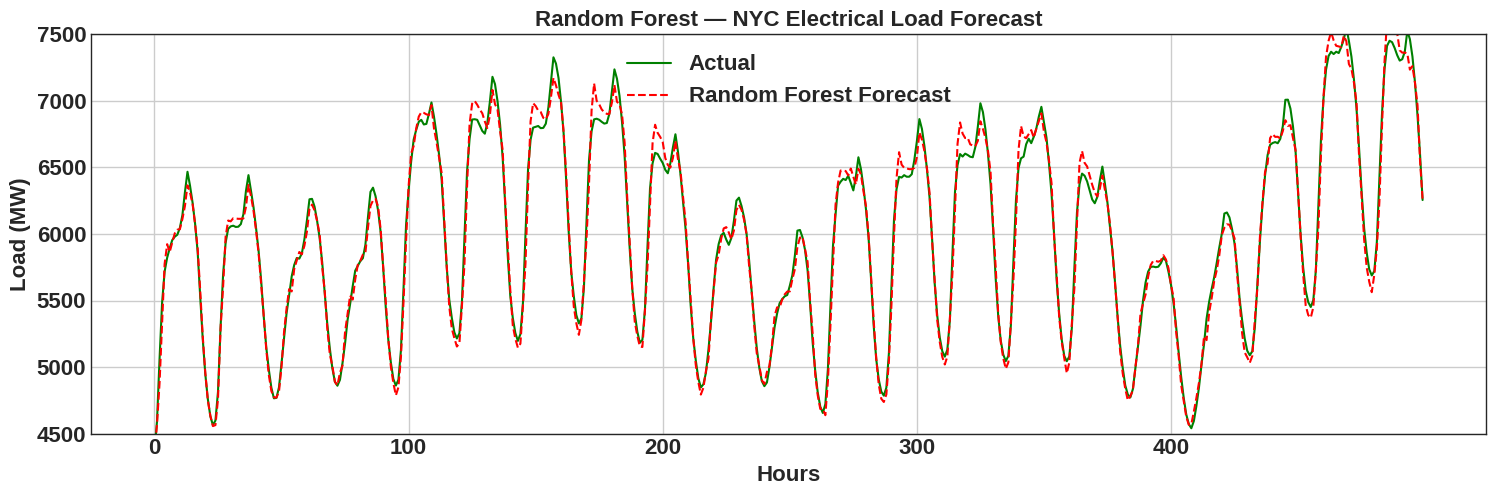

✅ Saved: rf_forecast.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,5))

plt.plot(y_test_gbm.values[:500], label='Actual', color='green', linewidth=1.5)
plt.plot(y_pred_rf[:500], label='Random Forest Forecast', color='red', linewidth=1.5, linestyle='--')

# 🔥 Fix Y-axis range (clean & consistent)
plt.ylim(4500, 7500)

# 🔥 Increase grid box spacing (clean values)
plt.xticks(np.arange(0, 500, 100), fontsize=16)   # wider horizontal boxes
plt.yticks(np.arange(4500, 7501, 500), fontsize=16)  # taller vertical boxes

# 🔥 Enable grid
plt.grid(True, linewidth=1)

plt.title('Random Forest — NYC Electrical Load Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Hours', fontsize=16)
plt.ylabel('Load (MW)', fontsize=16)

plt.tick_params(labelsize=16)
plt.legend(fontsize=16)

plt.tight_layout()
plt.savefig('rf_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: rf_forecast.png")

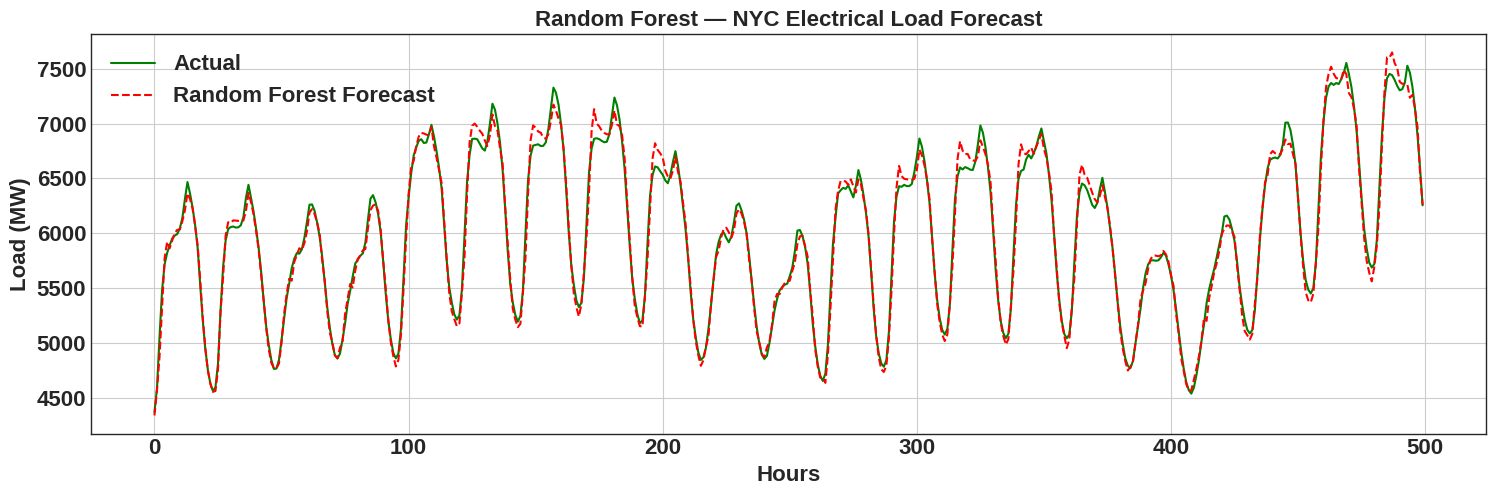

✅ Saved: rf_forecast.png


In [ ]:
plt.figure(figsize=(15,5))
plt.plot(y_test_gbm.values[:500], label='Actual',              color='green', linewidth=1.5)
plt.plot(y_pred_rf[:500],         label='Random Forest Forecast', color='red', linewidth=1.5, linestyle='--')
plt.title('Random Forest — NYC Electrical Load Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Hours', fontsize=16)
plt.ylabel('Load (MW)', fontsize=16)
plt.tick_params(labelsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig('rf_forecast.png', dpi=650, bbox_inches='tight')
plt.show()
print("✅ Saved: rf_forecast.png")

Cell 9 — RF Feature Importance

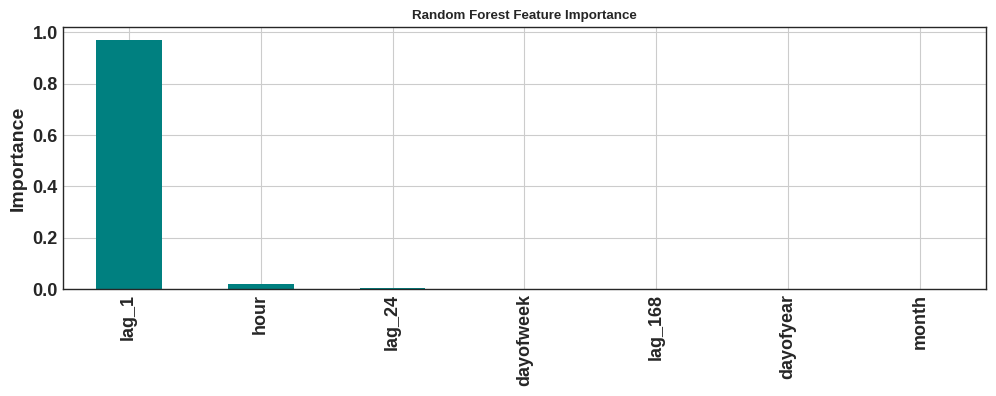

✅ Saved: rf_feature_importance.png


In [ ]:
feat_imp = pd.Series(
    model_rf.feature_importances_,
    index=features
).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10,4), color='teal',
              title='Random Forest Feature Importance')
plt.ylabel("Importance", fontsize=14)
plt.tick_params(labelsize=13)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: rf_feature_importance.png")

Final Comparison — Sabhi 6 Models

Cell 10 — Updated Comparison Table + Bar Chart

In [ ]:
results_all = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'GBM', 'Random Forest'],
    'RMSE':  [rmse,      rmse_gru,  rmse_gbm,  rmse_rf],
    'MAE':   [mae,       mae_gru,   mae_gbm,   mae_rf],
    'MAPE':  [mape,      mape_gru,  mape_gbm,  mape_rf],
    'R2':    [r2,   r2_gru,    r2_gbm,    r2_rf]
})

print("\n📊 All Models Comparison:")
print(results_all.sort_values('RMSE').to_string(index=False))

best = results_all.loc[results_all['RMSE'].idxmin()]

print(f"\n🏆 Best Model: {best['Model']}")
print(f"   RMSE : {best['RMSE']:.2f} MW")
print(f"   MAE  : {best['MAE']:.2f} MW")
print(f"   MAPE : {best['MAPE']:.2f} %")
print(f"   R2   : {best['R2']:.4f}")


📊 All Models Comparison:
        Model      RMSE       MAE     MAPE       R2
          GBM 62.402029 43.965151 0.750611 0.997057
Random Forest 72.935034 51.043366 0.865826 0.995980
         LSTM 75.463479 55.130007 0.972787 0.995693
          GRU 81.355036 58.233130 0.997755 0.994995

🏆 Best Model: GBM
   RMSE : 62.40 MW
   MAE  : 43.97 MW
   MAPE : 0.75 %
   R2   : 0.9971


Cell 11 — Final Bar Chart (6 Models)

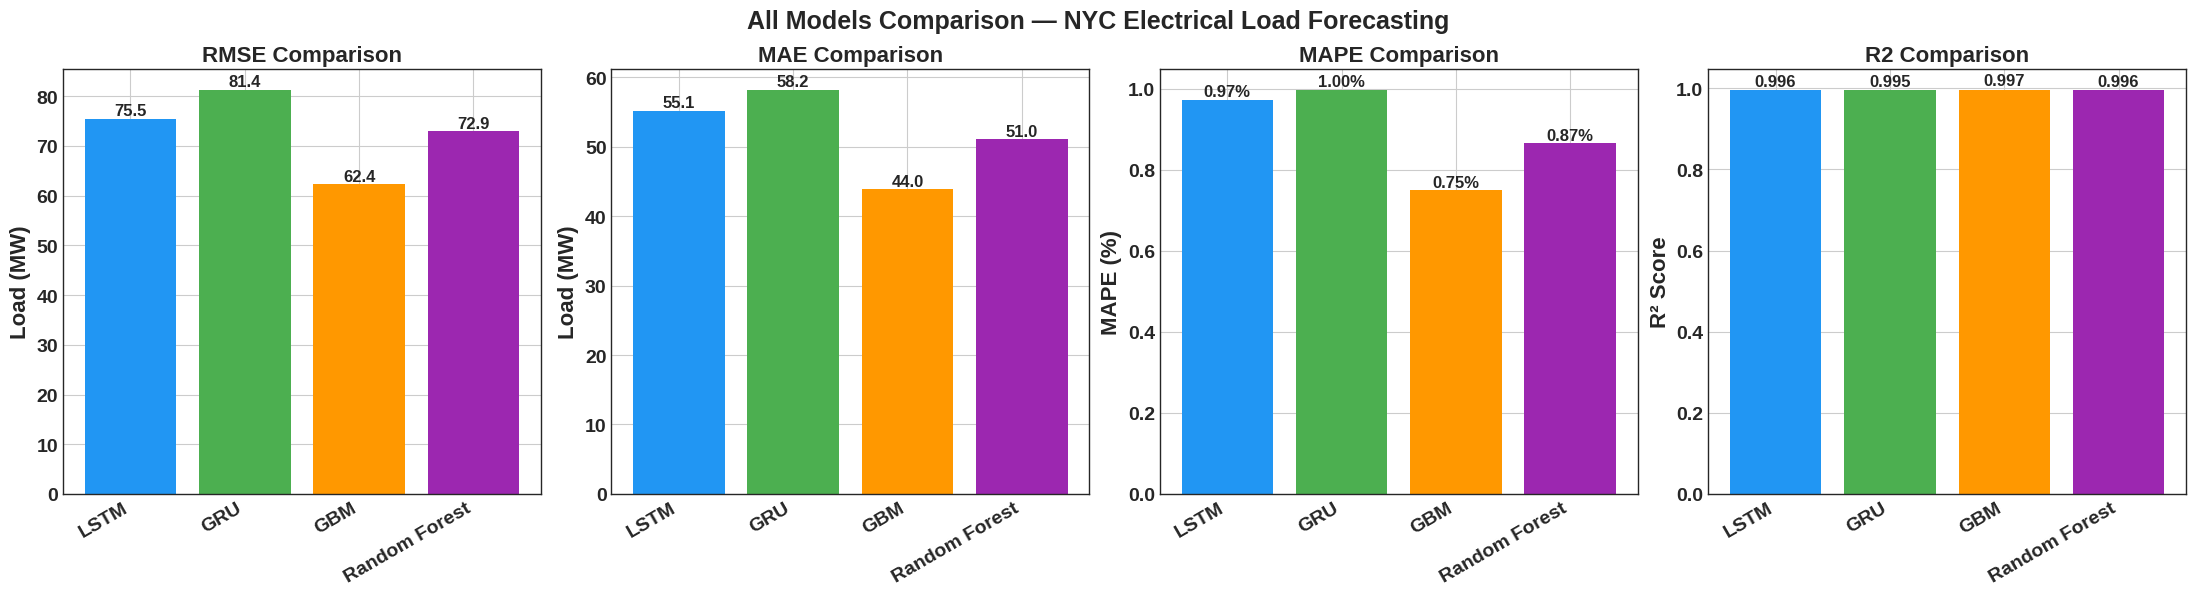

✅ Saved: all_models_comparison.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Re-defining results_all for robustness against kernel state loss
results_all = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'GBM', 'Random Forest'],
    'RMSE':  [rmse,      rmse_gru,  rmse_gbm,  rmse_rf],
    'MAE':   [mae,       mae_gru,   mae_gbm,   mae_rf],
    'MAPE':  [mape,      mape_gru,  mape_gbm,  mape_rf],
    'R2':    [r2,   r2_gru,    r2_gbm,    r2_rf]
})

colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0']

fig, axes = plt.subplots(1, 4, figsize=(22, 6))  # 4 plots now

for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE', 'R2']):
    ax.bar(results_all['Model'], results_all[metric], color=colors)
    ax.set_title(f'{metric} Comparison', fontsize=16, fontweight='bold')

    if metric == 'MAPE':
        ylabel = 'MAPE (%)'
    elif metric == 'R2':
        ylabel = 'R² Score'
    else:
        ylabel = 'Load (MW)'

    ax.set_ylabel(ylabel, fontsize=16)
    ax.tick_params(labelsize=14) # Increased tick label size
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=14)

    for i, v in enumerate(results_all[metric]):
        if metric == 'MAPE':
            label = f'{v:.2f}%'
            offset = 0.01 * v
        elif metric == 'R2':
            label = f'{v:.3f}'
            offset = 0.01
        else:
            label = f'{v:.1f}'
            offset = 0.01 * v

        ax.text(i, v + offset, label, ha='center', fontsize=12, fontweight='bold') # Annotation font size also adjusted

plt.suptitle('All Models Comparison — NYC Electrical Load Forecasting',
             fontsize=18, fontweight='bold') # Main title size also increased

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: all_models_comparison.png")

Cell 12 — Download All PNGs

In [ ]:
from google.colab import files
files.download('rf_forecast.png')
files.download('rf_feature_importance.png')
files.download('all_models_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Hybrid LSTM+GBM

Cell 1 — LSTM Predictions as GBM Features

In [ ]:
print("🔵 Training Hybrid LSTM+GBM...")

# Step 1: LSTM ke predictions lo (already trained hai)
lstm_train_pred = scaler.inverse_transform(model_lstm.predict(X_train))
lstm_test_pred  = scaler.inverse_transform(model_lstm.predict(X_test))

print(f"LSTM Train Pred Shape: {lstm_train_pred.shape}")
print(f"LSTM Test Pred Shape : {lstm_test_pred.shape}")

🔵 Training Hybrid LSTM+GBM...
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
LSTM Train Pred Shape: (35040, 1)
LSTM Test Pred Shape : (8760, 1)


Cell 2 — GBM Features + LSTM Predictions Combine karo

In [ ]:
print("🔵 Training Hybrid LSTM+GBM...")

# To ensure LSTM predictions align correctly with df_gbm's features and splits,
# we generate LSTM predictions for the specific time range covered by df_gbm.

# 1. Determine the time range for which LSTM predictions are needed.
#    df_gbm's index starts after lag features cause initial rows to be dropped.
#    To predict for df_gbm.index[0], we need SEQ_LEN hours prior to it.
start_time_for_lstm_gbm_pred = df_gbm.index[0] - pd.Timedelta(hours=SEQ_LEN)
end_time_for_lstm_gbm_pred   = df_gbm.index[-1]

# 2. Extract the corresponding 'Load_MW' data from nyc
#    (using nyc directly to maintain original timestamps before GBM feature engineering)
#    and scale it using the previously fitted scaler.
df_hourly_for_lstm_gbm_alignment = nyc.loc[start_time_for_lstm_gbm_pred : end_time_for_lstm_gbm_pred]
scaled_for_gbm_pred = scaler.transform(df_hourly_for_lstm_gbm_alignment[['Load_MW']])

# 3. Create LSTM sequences (X) from this scaled data.
X_for_gbm_pred = []
for i in range(SEQ_LEN, len(scaled_for_gbm_pred)):
    X_for_gbm_pred.append(scaled_for_gbm_pred[i-SEQ_LEN:i])
X_for_gbm_pred = np.array(X_for_gbm_pred)

# 4. Get predictions for the entire aligned dataset using the trained LSTM model.
lstm_full_pred_scaled = model_lstm.predict(X_for_gbm_pred)
lstm_full_pred = scaler.inverse_transform(lstm_full_pred_scaled)

# 5. Create a Pandas Series for these predictions, indexed by df_gbm.index
#    This ensures perfect alignment with the GBM features.
lstm_pred_series_aligned = pd.Series(lstm_full_pred.flatten(), index=df_gbm.index)

# Use the 'split' variable previously calculated for GBM data (X_gbm) in cell 'qrVSlXj_vgUf'
# 'split' was defined as `int(len(X_gbm) * 0.8)`

# 6. Prepare GBM features (df_gbm_train, df_gbm_test) and align LSTM predictions.
df_gbm_train = df_gbm[features].iloc[:split].copy()
df_gbm_test  = df_gbm[features].iloc[split:].copy()

# Add LSTM predictions as an extra feature to the GBM train/test sets.
df_gbm_train['lstm_pred'] = lstm_pred_series_aligned.iloc[:split].values
df_gbm_test['lstm_pred']  = lstm_pred_series_aligned.iloc[split:].values

# 7. Prepare the target variables for the hybrid model, aligned with GBM splits.
y_train_hybrid = y_gbm.iloc[:split].values
y_test_hybrid  = y_gbm.iloc[split:].values

print(f"Hybrid Train: {df_gbm_train.shape}")
print(f"Hybrid Test : {df_gbm_test.shape}")

🔵 Training Hybrid LSTM+GBM...
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step
Hybrid Train: (34924, 8)
Hybrid Test : (8732, 8)


Cell 3 — Hybrid GBM Train

In [ ]:
features_hybrid = features + ['lstm_pred']

model_hybrid = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model_hybrid.fit(df_gbm_train[features_hybrid], y_train_hybrid)
print("✅ Hybrid LSTM+GBM Training Done!")

✅ Hybrid LSTM+GBM Training Done!


Cell 4 — Predict + Metrics

In [ ]:
from sklearn.metrics import r2_score

y_pred_hybrid = model_hybrid.predict(df_gbm_test[features_hybrid])

rmse_hybrid, mae_hybrid, mape_hybrid, r2_hybrid = get_metrics(y_test_hybrid, y_pred_hybrid)

print(f"\n📊 Hybrid LSTM+GBM Results:")
print(f"   RMSE : {rmse_hybrid:.2f} MW")
print(f"   MAE  : {mae_hybrid:.2f} MW")
print(f"   MAPE : {mape_hybrid:.2f} %")
print(f"   R2   : {r2_hybrid:.4f}")


📊 Hybrid LSTM+GBM Results:
   RMSE : 50.97 MW
   MAE  : 33.76 MW
   MAPE : 0.57 %
   R2   : 0.9980


Cell 5 — Hybrid Plot

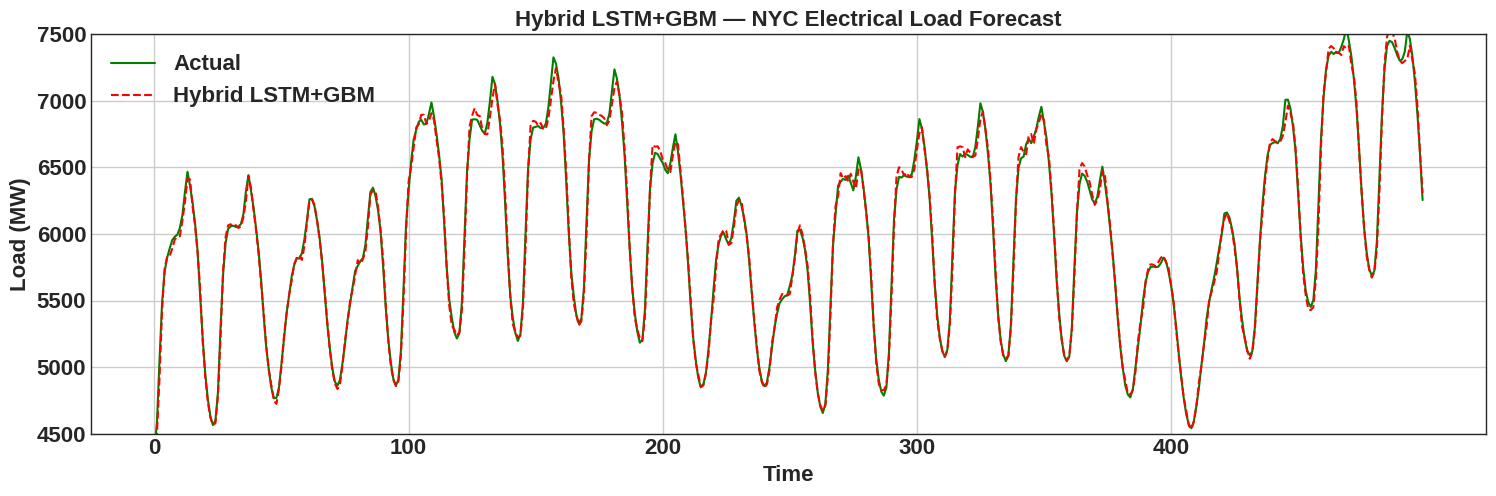

✅ Saved: hybrid_forecast.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,5))

plt.plot(y_test_hybrid[:500], label='Actual', color='green', linewidth=1.5)
plt.plot(y_pred_hybrid[:500], label='Hybrid LSTM+GBM', color='red', linewidth=1.5, linestyle='--')

# 🔥 Same grid settings as others
plt.ylim(4500, 7500)
plt.xticks(np.arange(0, 500, 100), fontsize=16)   # horizontal spacing
plt.yticks(np.arange(4500, 7501, 500), fontsize=16)  # vertical spacing

# 🔥 Enable grid
plt.grid(True, linewidth=1)

plt.title('Hybrid LSTM+GBM — NYC Electrical Load Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=16)
plt.ylabel('Load (MW)', fontsize=16)

plt.tick_params(labelsize=16)
plt.legend(fontsize=16)

plt.tight_layout()
plt.savefig('hybrid_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: hybrid_forecast.png")

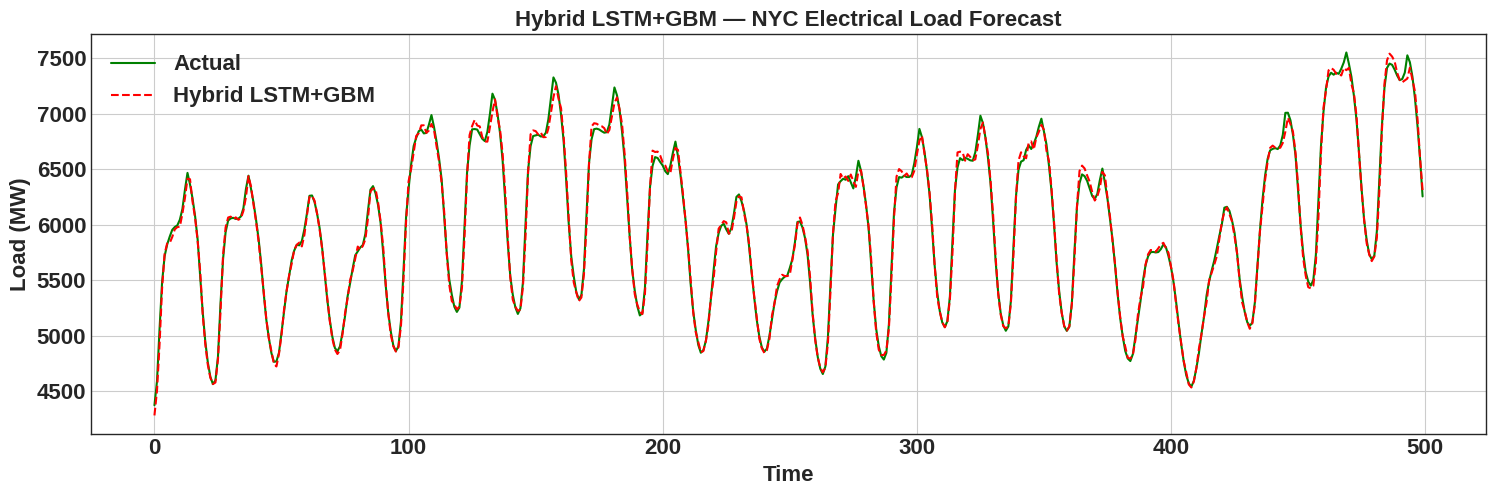

✅ Saved: hybrid_forecast.png


In [ ]:
plt.figure(figsize=(15,5))
plt.plot(y_test_hybrid[:500],  label='Actual',              color='green',   linewidth=1.5)
plt.plot(y_pred_hybrid[:500],  label='Hybrid LSTM+GBM',     color='red', linewidth=1.5, linestyle='--')
plt.title('Hybrid LSTM+GBM — NYC Electrical Load Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=16)
plt.ylabel('Load (MW)', fontsize=16)
plt.tick_params(labelsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig('hybrid_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: hybrid_forecast.png")

Cell 6 — Final Comparison (Sabhi 7 Models!)

In [ ]:
from sklearn.metrics import r2_score

# Create final comparison (without ARIMA & ANN)
results_final = pd.DataFrame({
    'Model': ['LSTM','GRU','GBM','Random Forest','Hybrid LSTM+GBM'],
    'RMSE':  [rmse,     rmse_gru,  rmse_gbm,  rmse_rf,  rmse_hybrid],
    'MAE':   [mae,      mae_gru,   mae_gbm,   mae_rf,   mae_hybrid],
    'MAPE':  [mape,     mape_gru,  mape_gbm,  mape_rf,  mape_hybrid],
    'R2':    [r2,       r2_gru,    r2_gbm,    r2_rf,    r2_hybrid]
})

print("\n📊 All Models Comparison:")
print(results_final.sort_values('RMSE').to_string(index=False))

# Best model based on RMSE
best = results_final.loc[results_final['RMSE'].idxmin()]
print(f"\n🏆 Best Model : {best['Model']}")
print(f"   RMSE       : {best['RMSE']:.2f} MW")
print(f"   MAE        : {best['MAE']:.2f} MW")
print(f"   MAPE       : {best['MAPE']:.2f} %")
print(f"   R2 Score   : {best['R2']:.4f}")


📊 All Models Comparison:
          Model      RMSE       MAE     MAPE       R2
Hybrid LSTM+GBM 50.965610 33.758082 0.574343 0.998037
            GBM 62.402029 43.965151 0.750611 0.997057
  Random Forest 72.935034 51.043366 0.865826 0.995980
           LSTM 75.463479 55.130007 0.972787 0.995693
            GRU 81.355036 58.233130 0.997755 0.994995

🏆 Best Model : Hybrid LSTM+GBM
   RMSE       : 50.97 MW
   MAE        : 33.76 MW
   MAPE       : 0.57 %
   R2 Score   : 0.9980


Cell 7 — Final Bar Chart (7 Models)

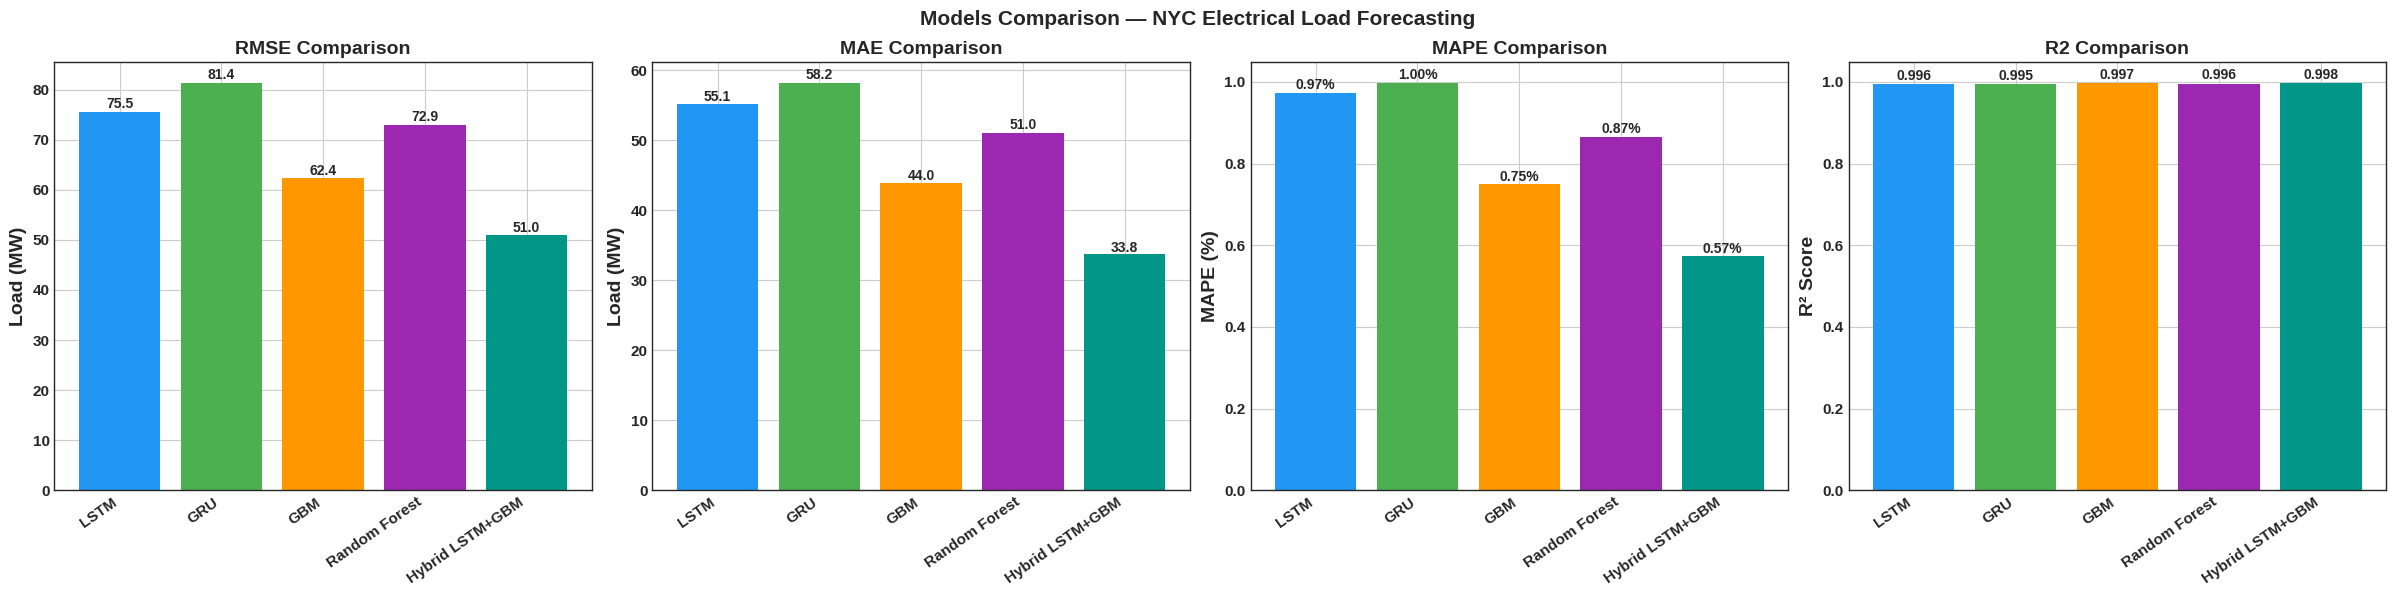

✅ Saved: final_models_comparison_with_r2.png


In [ ]:
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#009688']

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE', 'R2']):
    ax.bar(results_final['Model'], results_final[metric], color=colors)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')

    if metric == 'MAPE':
        ylabel = 'MAPE (%)'
    elif metric == 'R2':
        ylabel = 'R² Score'
    else:
        ylabel = 'Load (MW)'

    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(labelsize=11)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')

    for i, v in enumerate(results_final[metric]):
        if metric == 'MAPE':
            label = f'{v:.2f}%'
        elif metric == 'R2':
            label = f'{v:.3f}'
        else:
            label = f'{v:.1f}'
        ax.text(i, v + 0.01*abs(v), label, ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Models Comparison — NYC Electrical Load Forecasting',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('final_models_comparison_with_r2.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: final_models_comparison_with_r2.png")

Cell 8 — Combined Forecast (Sabhi 7 Models ek graph mein!)

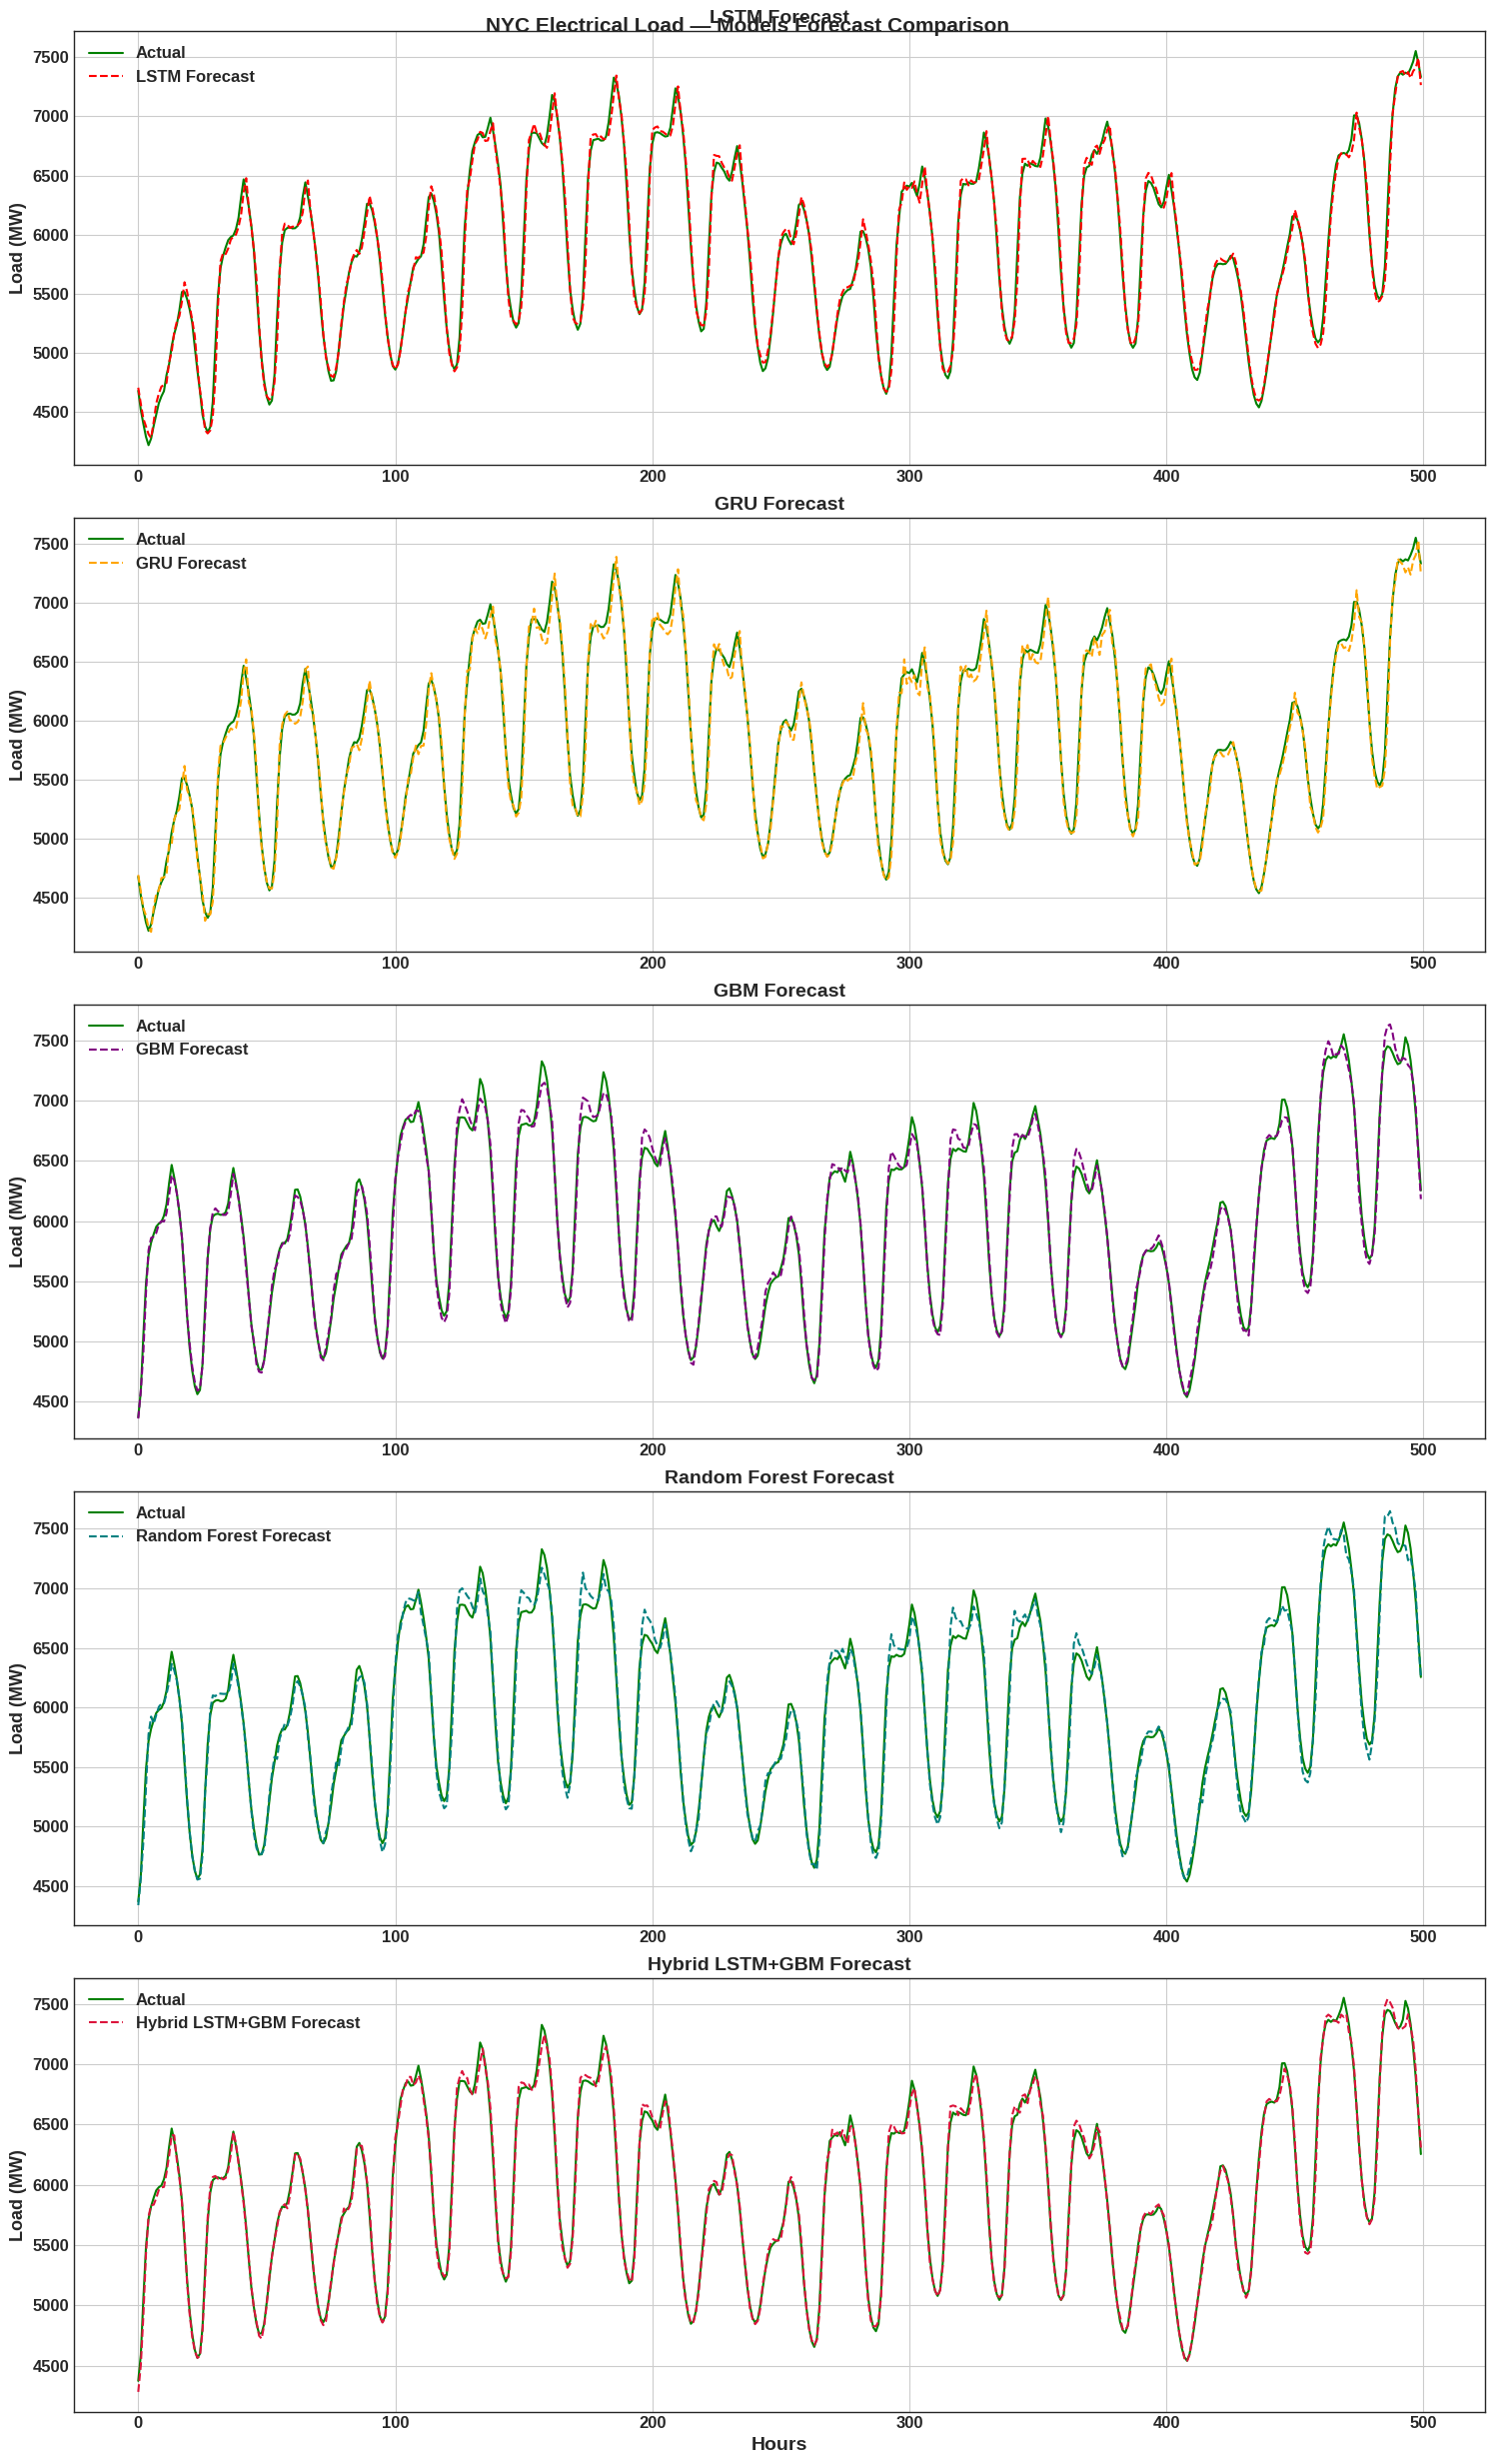

✅ Saved: final_5_models_forecast.png


In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(15, 25))
actual = y_actual[:500].flatten()

plots = [
    (actual,                  y_pred[:500],              'LSTM',            'red'),
    (actual,                  y_pred_gru[:500],          'GRU',             'orange'),
    (y_test_gbm.values[:500], y_pred_gbm[:500],          'GBM',             'purple'),
    (y_test_gbm.values[:500], y_pred_rf[:500],           'Random Forest',   'teal'),
    (y_test_hybrid[:500],     y_pred_hybrid[:500],       'Hybrid LSTM+GBM', 'crimson'),
]

for ax, (act, pred, name, color) in zip(axes, plots):
    ax.plot(act,  label='Actual',           color='green', linewidth=1.5)
    ax.plot(pred, label=f'{name} Forecast', color=color,   linewidth=1.5, linestyle='--')
    ax.set_title(f'{name} Forecast', fontsize=14, fontweight='bold')
    ax.set_ylabel('Load (MW)', fontsize=13)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=12)

axes[-1].set_xlabel('Hours', fontsize=14)

plt.suptitle('NYC Electrical Load — Models Forecast Comparison',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('final_5_models_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: final_5_models_forecast.png")

Cell 9 — Download All

In [ ]:
from google.colab import files
files.download('hybrid_forecast.png')
files.download('final_models_comparison_with_r2.png')
files.download('final_5_models_forecast.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

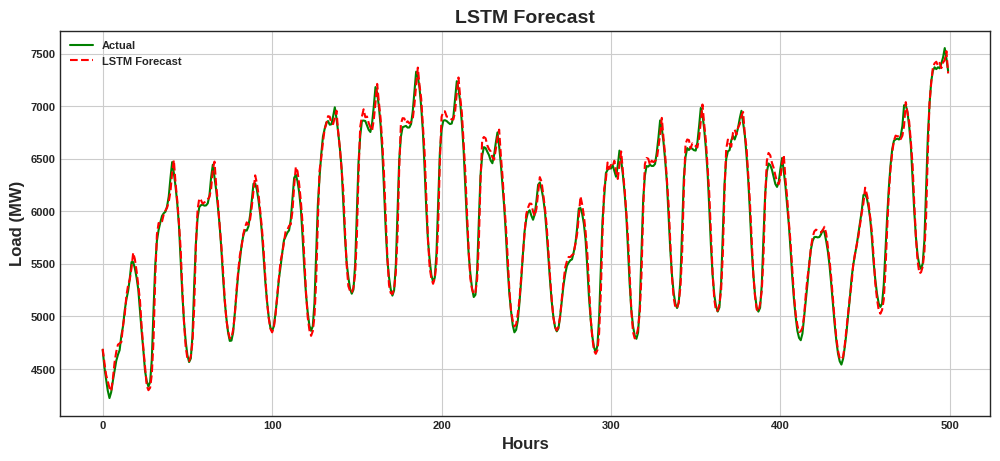

✅ Saved: lstm_forecast.png


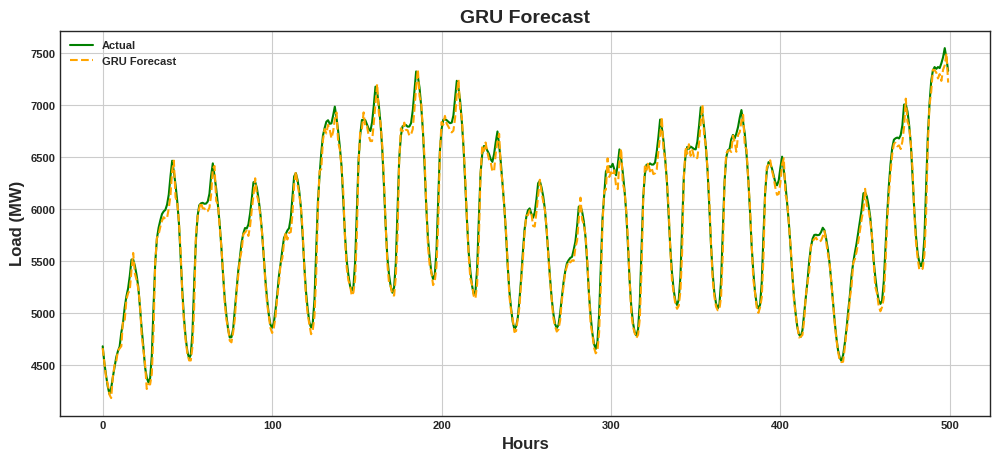

✅ Saved: gru_forecast.png


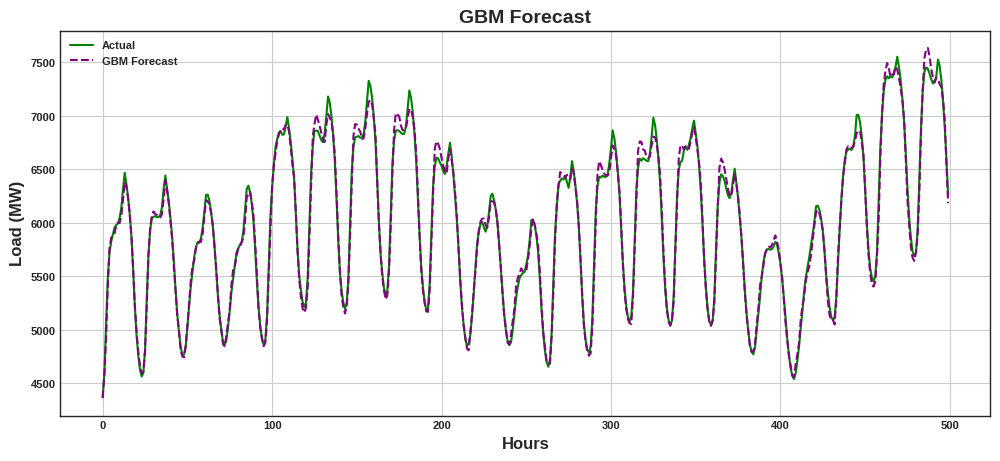

✅ Saved: gbm_forecast.png


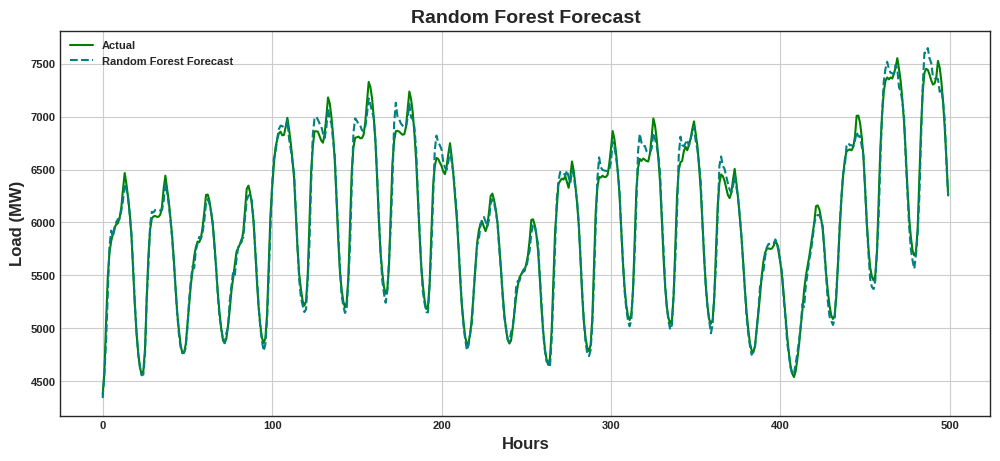

✅ Saved: random_forest_forecast.png


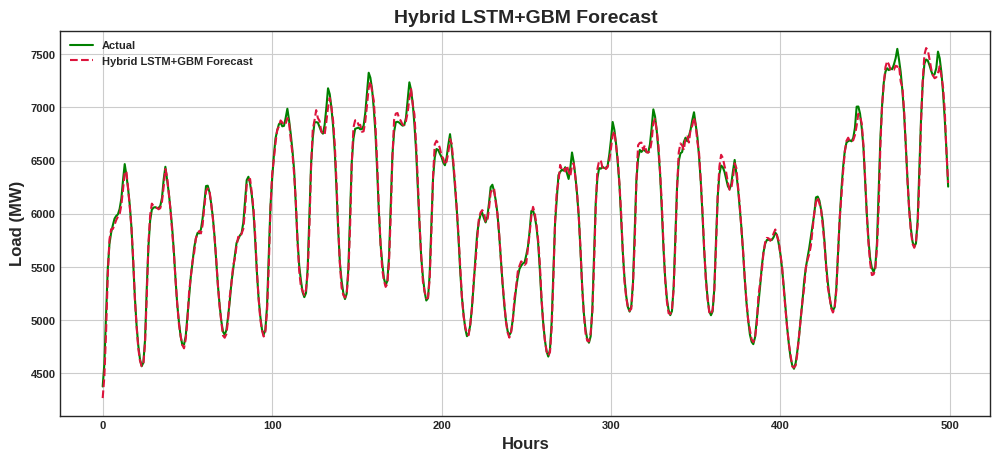

✅ Saved: hybrid_lstm+gbm_forecast.png


In [ ]:
models = [
    (y_actual[:500].flatten(), y_pred[:500],              'LSTM',            'red'),
    (y_actual[:500].flatten(), y_pred_gru[:500],          'GRU',             'orange'),
    (y_test_gbm.values[:500], y_pred_gbm[:500],           'GBM',             'purple'),
    (y_test_gbm.values[:500], y_pred_rf[:500],            'Random Forest',   'teal'),
    (y_test_hybrid[:500],     y_pred_hybrid[:500],        'Hybrid LSTM+GBM', 'crimson'),
]

for act, pred, name, color in models:
    plt.figure(figsize=(12, 5))

    plt.plot(act, label='Actual', color='green', linewidth=1.5)
    plt.plot(pred, label=f'{name} Forecast', color=color, linestyle='--', linewidth=1.5)

    plt.title(f'{name} Forecast', fontsize=14, fontweight='bold')
    plt.xlabel('Hours', fontsize=12)
    plt.ylabel('Load (MW)', fontsize=12)
    plt.legend()

    filename = f"{name.lower().replace(' ', '_')}_forecast.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')

    plt.show()

    print(f"✅ Saved: {filename}")